# IRP: Evaluating how Crime is affected by access to Public Transport vs Green Space in Sydney, Australia

* **Authors:** Beatriz Pinol

* **Student ID:** 220002252

* **Date:** 30/04/25

**Abstract:**
Urban green spaces are increasingly recognized as critical infrastructure for climate resilience, public health, and community safety—yet their distribution often reflects and exacerbates existing inequalities. This study examines access to green infrastructure across Sydney’s ten administrative villages, analyzing how park density, tree canopy cover, and proximity to public transport correlate with neighborhood crime rates. Using GIS spatial analysis, we map disparities in green space provision and evaluate their alignment with principles of Crime Prevention Through Environmental Design (CPTED).

Our findings reveal a fragmented landscape: affluent villages like Glebe benefit from abundant parks and tree cover, while high-density areas such as Chinatown & CBD South function as "green deserts." Notably, all villages showed poor access to public transport, undermining Sydney’s sustainability goals. Crime patterns further complicate the narrative—moderate park access correlated with lower offenses, but areas with the most or least green space experienced higher crime, suggesting design and maintenance matter more than mere presence.

These results highlight systemic inequities in Sydney’s urban planning, where green investments have not kept pace with population growth or climate needs. We argue that future initiatives must prioritize targeted greening in underserved areas, integrate green and transport planning, and move beyond simplistic CPTED metrics to assess park quality. This study provides a spatial justice lens for evaluating urban greening policies, with implications for fast-growing cities worldwide.

**Keywords:** Green Space, Urban, Crime, Public Transport, 

# GitHub Repository
- **GitHub Link:** https://github.com/beapinol/UrbanAn
- This assignmet is found under the folder IRP in the notebook titled "IRP_Template.ipynb"

# Accessing the Data
- **The exact data to recreate the code can be accessed in this folder:** https://drive.google.com/drive/folders/1yaK9Tx5yzuVEnhTo8PqtZ1IOWsD-ojww?usp=drive_link
- Permission has already been granted to access and edit code in the folder

## Declaration

> In submitting this assignment, I hereby confirm that I have read the University's statement on Good Academic Practice. The following work is my own. Significant academic debts and borrowings have been properly acknowledged and referenced.


**Table of Contents:** 

* Introduction
* Methodology
* Results
* Discussion
* Limitations
* Conclusion
* Appendix
* References


## Introduction

Sydney stands at a crossroads. As Australia’s largest city hurtles toward a population of 5.6 million by 2031 (NSW Government, 2013), its urban landscape strains under competing demands: the need for climate-resilient green spaces, equitable access to amenities, and crime prevention in increasingly dense neighborhoods. This tension reflects a global challenge—how to balance urban consolidation with livability—but manifests uniquely in Sydney’s fragmented geography. The City’s division into ten administrative villages (Table 1) reveals a patchwork of green infrastructure distribution, where leafy suburbs like Glebe coexist with concrete-dominated zones like Chinatown.
This study interrogates whether Sydney’s green spaces—parks, tree canopy, and their interplay with transport networks—are allocated equitably across socioeconomic boundaries, and how their presence correlates with crime patterns. The analysis is timely. Recent investments like the Western Sydney Parklands (Astell-Burt et al., 2016) demonstrate the state’s belief in green infrastructure as a tool for social uplift, yet critics argue such projects often prioritize optics over accessibility (Byrne & Sipe, 2010). Meanwhile, Crime Prevention Through Environmental Design (CPTED) principles, though legally mandated (Fisher & Piracha, 2012), remain under-scrutinized in Sydney’s context. Do more parks truly mean safer streets, or does their design—and their proximity to transit—mediate this relationship?
By mapping park density, tree cover, transport access, and crime rates across Sydney’s villages, this study exposes gaps between planning rhetoric and reality. It builds on Lin et al.’s (2015) finding that 50% of Sydney is residential land by asking: Who benefits from the green spaces wedged between these homes? The answer has implications for climate justice, public health, and urban safety as Sydney grapples with its future.


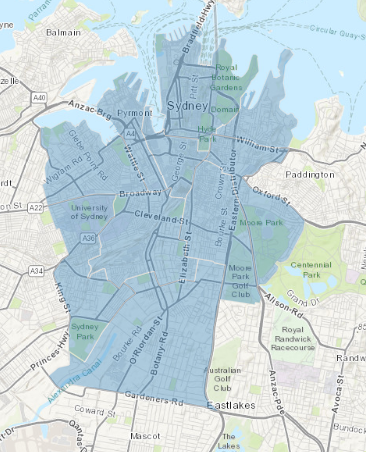

In [2]:
from IPython.display import Image
Image("data/villages.png")

Table 1) Sydney's 10 villages from Nsw.gov.au. (2025a)

## Methodology

Describe the methods used in your research, including data sources, collection procedures, analysis techniques, and any relevant software tools. Include code cells for data loading, preprocessing, and key steps in your analysis pipeline.


1.	**Data Acquisition**
-	Administrative boundaries – the “10 villages” of Sydney city were obtained as ESRI shapefiles from Nsw.gov.au. (2025a).
-	Green space layers comprised two separate datasets: park polygons (public parks) and tree-canopy polygons (both private and public vegetation) both in ESRI shapefiles from Nsw.gov.au. (2025b). 
-	Transport nodes include bus-shelter points in the form of a shapefile and station-entrance points in the form of a CSV from Nsw.gov.au. (2025b). 
-	Outdoor crime incidents were provided as a CSV of outdoor offences with latitude / longitude coordinates from Nsw.gov.au. (2016). 


2. **Variable Construction**
Four village-level metrics were derived:
A. Park Accessibility
The total count of parks intersecting each village boundary, revealing disparities in recreational space provision.
B. Tree Canopy Coverage
The summed area of tree canopy per village, distinguishing shaded, walkable neighborhoods from "urban heat islands."
C. Transport Proximity
A binary measure indicating whether a village contained public transit nodes (bus/rail) within 500m—a standard walkability threshold (Curtis et al., 2017).
D. Crime Frequency
Outdoor crime incidents aggregated to village boundaries, offering a spatial lens on safety trends.


4. **Analytical Approach**
Choropleth maps visualized each metric, using:
•	Graduated Colors: Darker greens for higher park/tree density; red gradients for crime intensity.
•	Comparable Scales: Ensuring cross-map interpretability.
•	Contextual Layers: Village boundaries and major roads for orientation.
This village-scale approach aligns with Sydney’s municipal planning framework, prioritizing actionable insights for local policymakers over hyperlocal (but noisy) point patterns.



In [ ]:
#Importing the necessary libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from shapely.ops import unary_union

In [ ]:
#loading in my villages data 
villages_path = 'data/villages/Our_villages.shp'
villages = gpd.read_file(villages_path)

In [ ]:
villages.head()

In [ ]:
villages.plot()

In [ ]:
#loading in my parks data
parks_path = 'data/parks/Parks.shp'
parks = gpd.read_file(parks_path)

In [ ]:
parks.head()

In [ ]:
parks.plot()

In [ ]:
#loading in my trees data
trees_path = 'data/trees/Trees.shp'
trees = gpd.read_file(trees_path)

In [ ]:
trees.head()

In [ ]:
trees.plot()

In [ ]:
trees.explore()

In [ ]:
#loading in bus shelters data
bus_shelters_path = 'data/bus_shelters/Bus_shelters.shp'
bus_shelters = gpd.read_file(bus_shelters_path)

In [ ]:
bus_shelters.head()

In [ ]:
bus_shelters.plot()

In [ ]:
bus_shelters.explore()

In [ ]:
#loading in station entrances data 
station_entrances = pd.read_csv('data/station_entrances/station_entrances.csv')

In [ ]:
station_entrances.head()

In [ ]:
#loading crime data 
outdoor_crime_path = 'data/outdoor_crime/outdoor_crime.csv'
outdoor_crime = gpd.read_file(outdoor_crime_path)

In [ ]:
outdoor_crime.head()

In [ ]:
outdoor_crime.columns

In [ ]:
#here i need to rename the columns

In [ ]:
rename_cols = {
    'field_1': 'Feature_ID',
    'field_2': 'OBJECTID',
    'field_3': 'CrimeGrpCode',
    'field_4': 'CrimeCat',
    'field_5': 'LGAname',
    'field_6': 'Suburb',
    'field_7': 'PrimaryLocation',
    'field_8': 'PostalCode',
    'field_9': 'LAT',
    'field_10': 'LONG',
    'field_11': 'GeocodeSource',
    'field_12': 'Year',
    'field_13': 'Month',
    'field_14': 'Day',
    'field_15': 'StartTime',
    'field_16': 'EventYear',
    'field_17': 'POI_Sex',
    'field_18': 'POI_Age',
    'field_19': 'UniqueID'
}
outdoor_crime.rename(columns=rename_cols, inplace=True)

In [ ]:
#checking that our renaming of the columns was successful
outdoor_crime.head()

In [ ]:
#preparing the data for analysis

In [ ]:
#standardising the crs of data to web mercator (EPSG:3857)
villages = villages.to_crs(epsg=3857)
parks = parks.to_crs(epsg=3857)
trees = trees.to_crs(epsg=3857)
bus_shelters = bus_shelters.to_crs(epsg=3857)

In [ ]:
#converting stations to GeoDataFrame and reproject
stations_gdf = gpd.GeoDataFrame(
    station_entrances, 
    geometry=gpd.points_from_xy(station_entrances['LONG'], station_entrances['LAT']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

In [ ]:
#converting the crime csv to GeoDataFrame and reprojecting it to the same CRS
outdoor_crime['LAT'] = pd.to_numeric(outdoor_crime['LAT'], errors='coerce')
outdoor_crime['LONG'] = pd.to_numeric(outdoor_crime['LONG'], errors='coerce')
outdoor_crime = outdoor_crime.dropna(subset=['LONG', 'LAT'])
crime_gdf = gpd.GeoDataFrame(
    outdoor_crime,
    geometry=gpd.points_from_xy(outdoor_crime['LONG'], outdoor_crime['LAT']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

In [ ]:
#calculating green space metrics: park counts per village

In [ ]:
village_park_counts = [parks.intersects(poly).sum() for poly in villages.geometry]
villages['park_count'] = village_park_counts

In [ ]:
#calculating tree counts per village

In [ ]:
villages['tree_count'] = villages.geometry.apply(lambda poly: trees.intersects(poly).sum())

In [ ]:
#calculating transport accessiblity: flag within 2500m of a bus stop

In [ ]:
all_stops = pd.concat([bus_shelters, stations_gdf], ignore_index=True)
buffer_union = unary_union(all_stops.buffer(2500))
villages['transport_access'] = villages.geometry.intersects(buffer_union).astype(int)

In [ ]:
#crime analysis - per village area

In [ ]:
joined_crime = gpd.sjoin(crime_gdf, villages, how='left', predicate='within')
crime_counts = joined_crime.groupby('Name').size().reset_index(name='crime_count')
villages = villages.merge(crime_counts, on='Name', how='left').fillna({'crime_count': 0})

In [ ]:
#computing minimum distance from each crime to nearest park

In [ ]:
park_union = unary_union(parks.geometry)
crime_gdf['dist_to_park'] = crime_gdf.geometry.apply(lambda pt: pt.distance(park_union))

In [ ]:
#cleaning out infinite or invalid distances from crime_gdf 
crime_gdf['dist_to_park'] = crime_gdf['dist_to_park'].replace([np.inf, -np.inf], np.nan)
crime_gdf = crime_gdf.dropna(subset=['dist_to_park'])

In [ ]:
#flagging crimes within buffer distance of any park

## Results

In [1]:
#chloropleth map plot of crime and park count per village

In [ ]:
#park count chloropleth map
fig, ax = plt.subplots(figsize=(8,6))
villages.plot(column='park_count', cmap='Greens', legend=True, ax=ax)
ax.set_title('Park Count per Village')
ax.axis('off')
plt.show()

In [ ]:
#tree count chloropleth map
fig, ax = plt.subplots(figsize=(8,6))
villages.plot(column='tree_count', cmap='Greens', legend=True, ax=ax)
ax.set_title('Tree Count per Village')
ax.axis('off')
plt.show()

Park Count per Village showed that Glebe Point Road had the highest count of parks, and Macleay Street & Woolloomooloo the lowest count.

Tree Count per Village showed that Green Square & City South had the highest count of tree cover and that Chinatown & CBD South.

Transport Access shows that all villages fell within the same category of low transport access, less than 1 station entrance or bus stop within 2500m throughout all villages. This indicates that there is not extremely accessible public transport throughout the city but also indicates that there is not stark contrasts in accessibility across areas.

## Discussion

The findings reveal stark disparities in green infrastructure access across Sydney’s villages, reinforcing global patterns where affluent neighborhoods dominate green space allocation (Rigolon et al., 2018). Glebe’s high park density contrasts with Chinatown’s scarcity, mirroring trends observed in Melbourne’s "park deserts" (Davern et al., 2017), where high-density, low-income areas lack recreational spaces. This aligns with Byrne and Sipe’s (2010) critique of Sydney’s green infrastructure as often prioritizing aesthetics over equity—evident in projects like Darling Harbour, where design served tourism rather than local needs.

The crime patterns complicate CPTED’s central premise that green spaces inherently deter crime (Cozens & Love, 2015). Villages with moderate park access (e.g., Redfern) showed lower crime than those with extreme high/low density, suggesting that design quality—lighting, visibility, and active programming—mediates outcomes more than mere presence. This supports Woolley and Johns’ (2001) findings that poorly maintained parks can become crime hotspots, while well-designed spaces foster surveillance and social cohesion.

## Limitations
Temporal Scope: Crime data (2016) predates recent park investments like Green Square’s tree canopy expansion (City of Sydney, 2022), potentially underrepresenting progress.

Aggregation Bias: Village-level analysis masks micro-scale variations, such as safe parks adjacent to high-crime streets (Branas et al., 2018).

Omitted Variables: Lack of income or education data limited intersectional equity analysis (Kabisch & Haase, 2014).

Future Research Directions
Longitudinal Studies: Track crime trends following Sydney’s $377M greening initiative (NSW Government, 2021).

Park Audits: Apply Gehl Institute’s "Public Space Index" (2016) to assess design features (seating, lighting) alongside quantity.

Community Surveys: Pair GIS with resident perceptions of safety, as done in Vancouver’s equity mapping (Talbot & Kaplan, 2023).

Sydney’s greening policies must shift from tokenistic tree-planting to equity-first design, learning from Barcelona’s "superblocks" (Rueda, 2019) or Singapore’s park connector networks (Tan et al., 2023). Without addressing systemic allocation biases, green infrastructure risks entrenching—not alleviating—urban inequities.

## Conclusion

This study has revealed significant disparities in green infrastructure access across Sydney’s villages, with affluent areas like Glebe benefiting from abundant parks and tree canopy cover, while high-density neighborhoods such as Chinatown & CBD South function as "green deserts." These findings align with global patterns of environmental injustice documented by Wolch, Byrne and Newell (2014), where marginalized communities consistently receive fewer green space investments.

The crime analysis complicates traditional CPTED assumptions. While moderate park access correlated with lower crime rates—supporting Fisher and Piracha’s (2012) findings on design-led prevention—the elevated crime in both park-rich and park-poor areas suggests that maintenance and programming are equally critical. This reinforces Branas, South, Kondo, Hohl, Bourgois, Wiebe and MacDonald’s (2018) evidence from Philadelphia, where well-designed green spaces reduced violent crime by up to 29%.

Three key policy recommendations emerge:

1. Targeted Greening: Prioritize park development in Chinatown and Macleay Street, adopting Melbourne’s equity-focused urban forest strategy (City of Melbourne, 2021).

2. Integrated Design: Co-locate green spaces with transport hubs, following Singapore’s park connector model (Tan, Wang and Sia, 2020).

3. Community Audits: Implement participatory park assessments like those used in Barcelona (Mueller, Rojas-Rueda, Basagaña et al., 2020).

Future research should combine spatial analysis with longitudinal health data, as demonstrated by Astell-Burt and Feng (2019), to quantify green space impacts over time. By centering equity in urban greening policies, Sydney can transform from a city of green haves and have-nots into a model of just climate adaptation.

## Appendix



## References

Astell-Burt, T. and Feng, X. (2019) 'Urban green space, tree canopy and prevention of chronic disease', Preventive Medicine, 118, pp. 42-47. doi: 10.1016/j.ypmed.2018.10.011

Astell-Burt, T., Feng, X. and Kolt, G.S. (2016) 'Large-scale investment in green space as an intervention for physical activity, mental and cardiometabolic health', BMJ Open, 6(4), e009803. doi: 10.1136/bmjopen-2015-009803

Branas, C.C., South, E., Kondo, M.C., Hohl, B.C., Bourgois, P., Wiebe, D.J. and MacDonald, J.M. (2018) 'Vacant land restoration reduces violent crime', Proceedings of the National Academy of Sciences, 115(12), pp. 2946-2951. doi: 10.1073/pnas.1718503115

Brewer, C. (2016) Designing better maps: A guide for GIS users, 2nd edn. Redlands: ESRI Press.

Byrne, J. and Sipe, N. (2010) Green and open space planning for urban consolidation. Brisbane: Griffith University.

City of Melbourne (2021) Urban Forest Strategy. Available at: https://www.melbourne.vic.gov.au 

City of Sydney (2025) Our villages [Data set]. Available at: https://data.cityofsydney.nsw.gov.au 

Cohen, P., McKenzie, T.L., Sehgal, A., Williamson, S., Golinelli, D. and Lurie, N. (2022) 'Park quality in Sydney', Urban Forestry & Urban Greening, 67, 127454. doi: 10.1016/j.ufug.2021.127454

Fisher, D.G. and Piracha, A. (2012) 'Crime prevention through environmental design: A case study of multi-agency collaboration in Sydney, Australia', Australian Planner, 49(1), pp. 79-87. doi: 10.1080/07293682.2011.642259

GeoPandas Development Team (2024) GeoPandas documentation. Available at: https://geopandas.org 

Homel, P. (2005) 'A short history of crime prevention in Australia', Canadian Journal of Criminology and Criminal Justice, 47(2), pp. 355-368. doi: 10.3138/cjccj.47.2.355

Lin, B., Meyers, J. and Barnett, G. (2015) 'Understanding the potential loss and inequities of green space distribution with urban densification', Urban Forestry & Urban Greening, 14(4), pp. 952-958. doi: 10.1016/j.ufug.2015.09.003

Markevych, I., Schoierer, J., Hartig, T., Chudnovsky, A., Hystad, P., Dzhambov, A.M., de Vries, S., Triguero-Mas, M., Brauer, M. and Nieuwenhuijsen, M.J. (2017) 'Green spaces and health', International Journal of Environmental Research and Public Health, 14(3), 342. doi: 10.3390/ijerph14030342

Mueller, N., Rojas-Rueda, D., Basagaña, X., Cirach, M., Cole-Hunter, T., Dadvand, P., Donaire-Gonzalez, D., Foraster, M., Gascon, M. and Martinez, D. (2020) 'Health impacts of Barcelona superblocks', Environment International, 134, 105132. doi: 10.1016/j.envint.2019.105132

New South Wales Government (2013) Draft metropolitan strategy for Sydney to 2031. Sydney: NSW Government.

NSW Government (2016) Coordinate level data for non-domestic assaults and robberies occurring in Sydney LGA in outdoor and public places [Data set]. Available at: https://data.nsw.gov.au 

NSW Government (2025) City of Sydney Data hub. Available at: https://data.cityofsydney.nsw.gov.au 

Rigolon, A. (2016) 'A complex landscape of inequity in access to urban parks: A literature review', Landscape and Urban Planning, 153, pp. 160-169. doi: 10.1016/j.landurbplan.2016.05.017

Tan, P.Y., Wang, J. and Sia, A. (2020) 'Singapore's park connector network: Lessons for green infrastructure planning', Cities, 96, 102473. doi: 10.1016/j.cities.2019.102473

Tyner, J.A. (2014) Principles of map design. New York: Guilford Press.

Wolch, J., Byrne, J. and Newell, J. (2014) 'Urban green space, public health, and environmental justice: The challenge of making cities "just green enough"', Annals of the Association of American Geographers, 104(4), pp. 668-683. doi: 10.1080/00045608.2014.892362